## Learning Objectives:
- Build a complete MLP from scratch using only NumPy
- Implement different optimization algorithms
- Compare optimizer performance on a real dataset
- Understand how optimizers affect training speed and convergence

## Topics Covered:
1. **MLP Architecture**: Flexible multi-layer network
2. **Optimizers**: Stochastic Gradient Descent (SGD), SGD with Momentum, Root mean square prop (RMSprop), Adam
3. **Training Loop**: Complete training process
4. **Comparison**: Visualize how different optimizers perform

## Dataset:
We'll use the **XOR problem** and **spiral dataset** - classic non-linear problems that require hidden layers to solve.

In [ ]:
# Step 1: Import Required Libraries
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split

# Set random seed for reproducibility
np.random.seed(42)

print("Libraries imported successfully!")
print(f"NumPy version: {np.__version__}")

Libraries imported successfully!
NumPy version: 2.0.2


# Step 2: Define Activation Functions

## Why Different Activations?
- **ReLU**: Most popular, prevents vanishing gradient
- **Sigmoid**: Output between 0-1, good for binary classification
- **Softmax**: For multi-class classification

Each activation has its derivative for backpropagation.

In [ ]:
# ACTIVATION FUNCTIONS


def relu(x):
    """ReLU: max(0, x)"""
    return np.maximum(0, x)

def relu_derivative(x):
    """Derivative of ReLU"""
    return (x > 0).astype(float)

def sigmoid(x):
    """Sigmoid: 1 / (1 + e^(-x))"""
    return 1 / (1 + np.exp(-np.clip(x, -500, 500)))  # Clip to prevent overflow

def sigmoid_derivative(x):
    """Derivative of sigmoid"""
    return x * (1 - x)

def softmax(x):
    """Softmax activation"""
    exp_x = np.exp(x - np.max(x, axis=1, keepdims=True))  # Numerical stability
    return exp_x / np.sum(exp_x, axis=1, keepdims=True)

def tanh(x):
    """Tanh activation"""
    return np.tanh(x)

def tanh_derivative(x):
    """Derivative of tanh"""
    return 1 - x**2

# Test activations
test_input = np.array([-2, -1, 0, 1, 2])
print("Activation Function Tests:")
print(f"Input: {test_input}")
print(f"ReLU: {relu(test_input)}")
print(f"Sigmoid: {sigmoid(test_input)}")
print(f"Tanh: {tanh(test_input)}")

Activation Function Tests:
Input: [-2 -1  0  1  2]
ReLU: [0 0 0 1 2]
Sigmoid: [0.11920292 0.26894142 0.5        0.73105858 0.88079708]
Tanh: [-0.96402758 -0.76159416  0.          0.76159416  0.96402758]


# Step 3: Weight Initialization

## Why Proper Initialization Matters?
- Random initialization breaks symmetry
- Proper scaling prevents vanishing/exploding gradients

## Xavier/He Initialization:
- **Xavier**: For sigmoid/tanh → $\sqrt{\frac{2}{n_{in} + n_{out}}}$
- **He**: For ReLU → $\sqrt{\frac{2}{n_{in}}}$

Where $n_{in}$ is the number of input neurons.

In [ ]:
# WEIGHT INITIALIZATION


def initialize_weights(layer_sizes, activation='relu'):
    """
    Initialize weights using He or Xavier initialization

    Parameters:
    - layer_sizes: List of layer sizes [input, hidden1, hidden2, ..., output]
    - activation: 'relu' or 'sigmoid/tanh'

    Returns:
    - weights: List of weight matrices
    - biases: List of bias vectors
    """
    weights = []
    biases = []

    for i in range(len(layer_sizes) - 1):
        n_in = layer_sizes[i]
        n_out = layer_sizes[i + 1]

        # He initialization for ReLU, Xavier for sigmoid/tanh
        if activation == 'relu' and i < len(layer_sizes) - 2:
            std = np.sqrt(2.0 / n_in)  # He initialization
        else:
            std = np.sqrt(2.0 / (n_in + n_out))  # Xavier initialization

        W = np.random.randn(n_in, n_out) * std
        b = np.zeros((1, n_out))

        weights.append(W)
        biases.append(b)

    return weights, biases

# Test initialization
test_architecture = [2, 4, 3, 2]  # Input=2, Hidden1=4, Hidden2=3, Output=2
test_weights, test_biases = initialize_weights(test_architecture)

print("Weight Initialization Test:")
print(f"Architecture: {test_architecture}")
for i, (W, b) in enumerate(zip(test_weights, test_biases)):
    print(f"\nLayer {i+1}:")
    print(f"  Weight shape: {W.shape}, Mean: {W.mean():.4f}, Std: {W.std():.4f}")
    print(f"  Bias shape: {b.shape}")

Weight Initialization Test:
Architecture: [2, 4, 3, 2]

Layer 1:
  Weight shape: (2, 4), Mean: 0.5509, Std: 0.6864
  Bias shape: (1, 4)

Layer 2:
  Weight shape: (4, 3), Mean: -0.4616, Std: 0.5318
  Bias shape: (1, 3)

Layer 3:
  Weight shape: (3, 2), Mean: -0.0581, Std: 0.5472
  Bias shape: (1, 2)


# Step 4: Forward Propagation

## Process:
For each layer $l$:
1. **Linear**: $z^{[l]} = a^{[l-1]} W^{[l]} + b^{[l]}$
2. **Activation**: $a^{[l]} = g(z^{[l]})$

We store all intermediate values for backpropagation.

## Cache:
We save $z$ and $a$ for each layer to use during backpropagation.

In [ ]:
# FORWARD PROPAGATION


def forward_propagation(X, weights, biases, activation='relu'):
    """
    Forward propagation through the network

    Parameters:
    - X: Input data (n_samples, n_features)
    - weights: List of weight matrices
    - biases: List of bias vectors
    - activation: Activation function to use

    Returns:
    - output: Final network output
    - cache: Dictionary containing all z and a values for backprop
    """
    cache = {'a': [X]}  # Store activations, starting with input
    cache['z'] = []      # Store pre-activations

    A = X
    num_layers = len(weights)

    for i in range(num_layers):
        # Linear transformation
        Z = np.dot(A, weights[i]) + biases[i]
        cache['z'].append(Z)

        # Activation function
        if i == num_layers - 1:  # Output layer
            A = sigmoid(Z)  # Binary classification
        else:  # Hidden layers
            if activation == 'relu':
                A = relu(Z)
            elif activation == 'sigmoid':
                A = sigmoid(Z)
            elif activation == 'tanh':
                A = tanh(Z)

        cache['a'].append(A)

    return A, cache

# Test forward propagation
X_test = np.random.randn(3, 2)  # 3 samples, 2 features
output, cache = forward_propagation(X_test, test_weights, test_biases)

print("Forward Propagation Test:")
print(f"Input shape: {X_test.shape}")
print(f"Output shape: {output.shape}")
print(f"Output:\n{output}")
print(f"\nNumber of layers: {len(cache['a']) - 1}")  # -1 because first is input

Forward Propagation Test:
Input shape: (3, 2)
Output shape: (3, 2)
Output:
[[0.50013002 0.4972567 ]
 [0.50027647 0.49416711]
 [0.5        0.5       ]]

Number of layers: 3


# Step 5: Loss Functions

## Binary Cross-Entropy Loss:
$$L = -\frac{1}{m} \sum_{i=1}^{m} [y_i \log(\hat{y}_i) + (1-y_i) \log(1-\hat{y}_i)]$$

Where:
- $m$ = number of samples
- $y_i$ = true label
- $\hat{y}_i$ = predicted probability

## Why Cross-Entropy?
- Penalizes confident wrong predictions heavily
- Works well with sigmoid/softmax outputs
- Gradient has nice mathematical properties

In [ ]:

# LOSS FUNCTIONS


def binary_cross_entropy(y_true, y_pred):
    """
    Binary cross-entropy loss

    Parameters:
    - y_true: True labels (n_samples, n_outputs)
    - y_pred: Predicted probabilities (n_samples, n_outputs)

    Returns:
    - loss: Scalar loss value
    """
    m = y_true.shape[0]
    # Clip predictions to prevent log(0)
    y_pred = np.clip(y_pred, 1e-7, 1 - 1e-7)
    loss = -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))
    return loss

def compute_accuracy(y_true, y_pred):
    """
    Compute classification accuracy

    Parameters:
    - y_true: True labels
    - y_pred: Predicted probabilities

    Returns:
    - accuracy: Percentage of correct predictions
    """
    predictions = (y_pred >= 0.5).astype(int)
    accuracy = np.mean(predictions == y_true)
    return accuracy * 100

# Test loss function
y_true_test = np.array([[1, 0], [0, 1], [1, 0]])
y_pred_test = np.array([[0.9, 0.1], [0.2, 0.8], [0.7, 0.3]])

loss = binary_cross_entropy(y_true_test, y_pred_test)
acc = compute_accuracy(y_true_test, y_pred_test)

print("Loss Function Test:")
print(f"True labels:\n{y_true_test}")
print(f"Predictions:\n{y_pred_test}")
print(f"Loss: {loss:.4f}")
print(f"Accuracy: {acc:.2f}%")

Loss Function Test:
True labels:
[[1 0]
 [0 1]
 [1 0]]
Predictions:
[[0.9 0.1]
 [0.2 0.8]
 [0.7 0.3]]
Loss: 0.2284
Accuracy: 100.00%


# Step 6: Backpropagation

## The Chain Rule Applied:
For each layer $l$ (going backwards):

1. **Output layer delta**:
   $$\delta^{[L]} = \frac{\partial L}{\partial a^{[L]}} = a^{[L]} - y$$

2. **Hidden layer delta**:
   $$\delta^{[l]} = (\delta^{[l+1]} \cdot W^{[l+1]T}) \odot g'(z^{[l]})$$

3. **Gradients**:
   - $\frac{\partial L}{\partial W^{[l]}} = (a^{[l-1]})^T \cdot \delta^{[l]}$
   - $\frac{\partial L}{\partial b^{[l]}} = \sum \delta^{[l]}$

Where $\odot$ is element-wise multiplication.

In [ ]:
# ============================================
# BACKPROPAGATION
# ============================================

def backward_propagation(y_true, weights, cache, activation='relu'):
    """
    Backward propagation to compute gradients

    Parameters:
    - y_true: True labels
    - weights: List of weight matrices
    - cache: Cache from forward propagation
    - activation: Activation function used

    Returns:
    - grads: Dictionary containing gradients for weights and biases
    """
    m = y_true.shape[0]
    num_layers = len(weights)
    grads = {'dW': [], 'db': []}

    # Output layer gradient
    dA = cache['a'][-1] - y_true  # For binary cross-entropy + sigmoid

    # Backward through each layer
    for i in reversed(range(num_layers)):
        # Current layer values
        Z = cache['z'][i]
        A_prev = cache['a'][i]

        # Compute dZ based on activation function
        if i == num_layers - 1:  # Output layer
            dZ = dA  # Already computed above
        else:  # Hidden layers
            if activation == 'relu':
                dZ = dA * relu_derivative(Z)
            elif activation == 'sigmoid':
                dZ = dA * sigmoid_derivative(cache['a'][i+1])
            elif activation == 'tanh':
                dZ = dA * tanh_derivative(cache['a'][i+1])

        # Compute gradients
        dW = np.dot(A_prev.T, dZ) / m
        db = np.sum(dZ, axis=0, keepdims=True) / m

        # Store gradients (in reverse order, will reverse later)
        grads['dW'].insert(0, dW)
        grads['db'].insert(0, db)

        # Gradient for previous layer
        if i > 0:
            dA = np.dot(dZ, weights[i].T)

    return grads

# Test backpropagation
y_true_test = np.array([[1, 0], [0, 1], [1, 0]])
grads = backward_propagation(y_true_test, test_weights, cache)

print("Backpropagation Test:")
print(f"Number of weight gradients: {len(grads['dW'])}")
for i, (dW, db) in enumerate(zip(grads['dW'], grads['db'])):
    print(f"\nLayer {i+1} gradients:")
    print(f"  dW shape: {dW.shape}, Mean: {dW.mean():.6f}")
    print(f"  db shape: {db.shape}, Mean: {db.mean():.6f}")

Backpropagation Test:
Number of weight gradients: 3

Layer 1 gradients:
  dW shape: (2, 4), Mean: -0.000441
  db shape: (1, 4), Mean: 0.000110

Layer 2 gradients:
  dW shape: (4, 3), Mean: 0.001078
  db shape: (1, 3), Mean: 0.000861

Layer 3 gradients:
  dW shape: (3, 2), Mean: -0.000010
  db shape: (1, 2), Mean: -0.001362


# Step 7: Optimization Algorithms

## Why Different Optimizers?
Standard gradient descent can be slow and get stuck. Modern optimizers adapt the learning rate and direction to converge faster.

## Optimizers We'll Implement:

### 1. **SGD (Stochastic Gradient Descent)**
$$W = W - \alpha \cdot \frac{\partial L}{\partial W}$$
- Simplest optimizer
- Fixed learning rate
- Can be slow and oscillate

### 2. **SGD with Momentum**
$$v = \beta v + \frac{\partial L}{\partial W}$$
$$W = W - \alpha \cdot v$$
- Adds "velocity" term
- Smooths updates
- Helps escape local minima

### 3. **RMSprop**
$$s = \beta s + (1-\beta) \left(\frac{\partial L}{\partial W}\right)^2$$
$$W = W - \frac{\alpha}{\sqrt{s + \epsilon}} \cdot \frac{\partial L}{\partial W}$$
- Adapts learning rate per parameter
- Good for non-stationary objectives

### 4. **Adam (Adaptive Moment Estimation)**
$$m = \beta_1 m + (1-\beta_1) \frac{\partial L}{\partial W}$$ (momentum)
$$v = \beta_2 v + (1-\beta_2) \left(\frac{\partial L}{\partial W}\right)^2$$ (RMSprop)
$$W = W - \frac{\alpha}{\sqrt{v + \epsilon}} \cdot m$$
- Combines momentum + RMSprop
- Most popular optimizer
- Works well out-of-the-box

In [ ]:

# OPTIMIZER: STOCHASTIC GRADIENT DESCENT (SGD)


def sgd_update(weights, biases, grads, learning_rate):
    """
    Standard SGD update

    W = W - learning_rate * dW
    """
    updated_weights = []
    updated_biases = []

    for i in range(len(weights)):
        W_new = weights[i] - learning_rate * grads['dW'][i]
        b_new = biases[i] - learning_rate * grads['db'][i]
        updated_weights.append(W_new)
        updated_biases.append(b_new)

    return updated_weights, updated_biases, {}

print("✓ SGD optimizer implemented")

✓ SGD optimizer implemented


In [ ]:

# OPTIMIZER: SGD WITH MOMENTUM


def momentum_update(weights, biases, grads, learning_rate, velocity, beta=0.9):
    """
    SGD with momentum update

    v = beta * v + dW
    W = W - learning_rate * v
    """
    updated_weights = []
    updated_biases = []

    # Initialize velocity if not exists
    if not velocity:
        velocity = {
            'vW': [np.zeros_like(W) for W in weights],
            'vb': [np.zeros_like(b) for b in biases]
        }

    for i in range(len(weights)):
        # Update velocity
        velocity['vW'][i] = beta * velocity['vW'][i] + grads['dW'][i]
        velocity['vb'][i] = beta * velocity['vb'][i] + grads['db'][i]

        # Update weights
        W_new = weights[i] - learning_rate * velocity['vW'][i]
        b_new = biases[i] - learning_rate * velocity['vb'][i]

        updated_weights.append(W_new)
        updated_biases.append(b_new)

    return updated_weights, updated_biases, velocity

print("✓ Momentum optimizer implemented")

✓ Momentum optimizer implemented


In [ ]:

# OPTIMIZER: RMSprop


def rmsprop_update(weights, biases, grads, learning_rate, cache, beta=0.9, epsilon=1e-8):
    """
    RMSprop update

    s = beta * s + (1 - beta) * dW^2
    W = W - learning_rate * dW / (sqrt(s) + epsilon)
    """
    updated_weights = []
    updated_biases = []

    # Initialize cache if not exists
    if not cache:
        cache = {
            'sW': [np.zeros_like(W) for W in weights],
            'sb': [np.zeros_like(b) for b in biases]
        }

    for i in range(len(weights)):
        # Update cache (exponential moving average of squared gradients)
        cache['sW'][i] = beta * cache['sW'][i] + (1 - beta) * grads['dW'][i]**2
        cache['sb'][i] = beta * cache['sb'][i] + (1 - beta) * grads['db'][i]**2

        # Update weights
        W_new = weights[i] - learning_rate * grads['dW'][i] / (np.sqrt(cache['sW'][i]) + epsilon)
        b_new = biases[i] - learning_rate * grads['db'][i] / (np.sqrt(cache['sb'][i]) + epsilon)

        updated_weights.append(W_new)
        updated_biases.append(b_new)

    return updated_weights, updated_biases, cache

print("✓ RMSprop optimizer implemented")

✓ RMSprop optimizer implemented


In [ ]:

# OPTIMIZER: Adam


def adam_update(weights, biases, grads, learning_rate, cache, t,
                beta1=0.9, beta2=0.999, epsilon=1e-8):
    """
    Adam optimizer update

    Combines momentum and RMSprop:
    m = beta1 * m + (1 - beta1) * dW  (momentum)
    v = beta2 * v + (1 - beta2) * dW^2  (RMSprop)
    m_corrected = m / (1 - beta1^t)  (bias correction)
    v_corrected = v / (1 - beta2^t)  (bias correction)
    W = W - learning_rate * m_corrected / (sqrt(v_corrected) + epsilon)
    """
    updated_weights = []
    updated_biases = []

    # Initialize cache if not exists
    if not cache:
        cache = {
            'mW': [np.zeros_like(W) for W in weights],
            'mb': [np.zeros_like(b) for b in biases],
            'vW': [np.zeros_like(W) for W in weights],
            'vb': [np.zeros_like(b) for b in biases]
        }

    for i in range(len(weights)):
        # Update biased first moment estimate (momentum)
        cache['mW'][i] = beta1 * cache['mW'][i] + (1 - beta1) * grads['dW'][i]
        cache['mb'][i] = beta1 * cache['mb'][i] + (1 - beta1) * grads['db'][i]

        # Update biased second moment estimate (RMSprop)
        cache['vW'][i] = beta2 * cache['vW'][i] + (1 - beta2) * grads['dW'][i]**2
        cache['vb'][i] = beta2 * cache['vb'][i] + (1 - beta2) * grads['db'][i]**2

        # Compute bias-corrected moment estimates
        m_corrected_W = cache['mW'][i] / (1 - beta1**t)
        m_corrected_b = cache['mb'][i] / (1 - beta1**t)
        v_corrected_W = cache['vW'][i] / (1 - beta2**t)
        v_corrected_b = cache['vb'][i] / (1 - beta2**t)

        # Update weights
        W_new = weights[i] - learning_rate * m_corrected_W / (np.sqrt(v_corrected_W) + epsilon)
        b_new = biases[i] - learning_rate * m_corrected_b / (np.sqrt(v_corrected_b) + epsilon)

        updated_weights.append(W_new)
        updated_biases.append(b_new)

    return updated_weights, updated_biases, cache

print("✓ Adam optimizer implemented")

✓ Adam optimizer implemented


# Step 8: Complete Training Function

This function brings everything together:
1. Initialize weights
2. Loop through epochs
3. Forward propagation
4. Compute loss
5. Backward propagation
6. Update weights using chosen optimizer
7. Track metrics

We'll store loss and accuracy history to compare optimizers later.

In [ ]:
# ============================================
# COMPLETE TRAINING FUNCTION
# ============================================

def train_mlp(X_train, y_train, X_test, y_test, layer_sizes,
              optimizer='sgd', learning_rate=0.01, epochs=1000,
              activation='relu', verbose=True, print_every=100):
    """
    Train MLP with specified optimizer

    Parameters:
    - X_train, y_train: Training data
    - X_test, y_test: Test data
    - layer_sizes: List of layer sizes [input, hidden1, ..., output]
    - optimizer: 'sgd', 'momentum', 'rmsprop', or 'adam'
    - learning_rate: Learning rate
    - epochs: Number of training epochs
    - activation: Activation function for hidden layers
    - verbose: Print training progress
    - print_every: Print frequency

    Returns:
    - weights, biases: Trained parameters
    - history: Training history (loss and accuracy)
    """
    # Initialize
    weights, biases = initialize_weights(layer_sizes, activation)
    optimizer_cache = {}
    t = 0  # Time step for Adam

    # History tracking
    history = {
        'train_loss': [],
        'test_loss': [],
        'train_acc': [],
        'test_acc': []
    }

    # Training loop
    for epoch in range(epochs):
        t += 1

        # Forward propagation
        output_train, cache = forward_propagation(X_train, weights, biases, activation)

        # Compute loss
        train_loss = binary_cross_entropy(y_train, output_train)
        train_acc = compute_accuracy(y_train, output_train)

        # Backward propagation
        grads = backward_propagation(y_train, weights, cache, activation)

        # Update weights based on optimizer
        if optimizer == 'sgd':
            weights, biases, optimizer_cache = sgd_update(
                weights, biases, grads, learning_rate
            )
        elif optimizer == 'momentum':
            weights, biases, optimizer_cache = momentum_update(
                weights, biases, grads, learning_rate, optimizer_cache
            )
        elif optimizer == 'rmsprop':
            weights, biases, optimizer_cache = rmsprop_update(
                weights, biases, grads, learning_rate, optimizer_cache
            )
        elif optimizer == 'adam':
            weights, biases, optimizer_cache = adam_update(
                weights, biases, grads, learning_rate, optimizer_cache, t
            )

        # Evaluate on test set
        output_test, _ = forward_propagation(X_test, weights, biases, activation)
        test_loss = binary_cross_entropy(y_test, output_test)
        test_acc = compute_accuracy(y_test, output_test)

        # Store history
        history['train_loss'].append(train_loss)
        history['test_loss'].append(test_loss)
        history['train_acc'].append(train_acc)
        history['test_acc'].append(test_acc)

        # Print progress
        if verbose and (epoch + 1) % print_every == 0:
            print(f"Epoch {epoch+1}/{epochs} | "
                  f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | "
                  f"Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.2f}%")

    return weights, biases, history

print("✓ Training function implemented")

✓ Training function implemented


# Step 9: Generate Dataset

We'll use the **Moons dataset** - a classic 2D dataset that requires non-linear decision boundaries.

## Moons Dataset:
- Two interleaving half circles
- Cannot be separated by a straight line
- Perfect for demonstrating MLP capabilities
- Easy to visualize

Let's generate 1000 samples and split into train/test sets.

Dataset Information:
Training samples: 800
Test samples: 200
Input features: 2
Output classes: 2


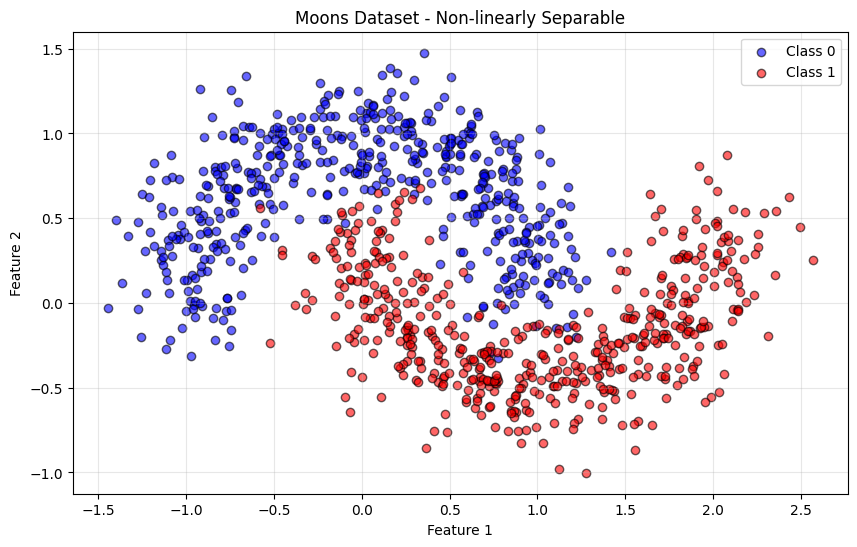

In [ ]:
# ============================================
# GENERATE DATASET
# ============================================

# Generate moons dataset
X, y = make_moons(n_samples=1000, noise=0.2, random_state=42)
y = y.reshape(-1, 1)  # Reshape for consistency

# Split into train and test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Dataset Information:")
print(f"Training samples: {X_train.shape[0]}")
print(f"Test samples: {X_test.shape[0]}")
print(f"Input features: {X_train.shape[1]}")
print(f"Output classes: {len(np.unique(y))}")

# Visualize dataset
plt.figure(figsize=(10, 6))
plt.scatter(X[y.flatten()==0, 0], X[y.flatten()==0, 1],
            c='blue', label='Class 0', alpha=0.6, edgecolors='k')
plt.scatter(X[y.flatten()==1, 0], X[y.flatten()==1, 1],
            c='red', label='Class 1', alpha=0.6, edgecolors='k')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Moons Dataset - Non-linearly Separable')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Step 10: Train MLP with Different Optimizers

Now we'll train the same network architecture with all four optimizers and compare their performance.

## Network Architecture:
- **Input**: 2 features
- **Hidden Layer 1**: 16 neurons (ReLU)
- **Hidden Layer 2**: 8 neurons (ReLU)
- **Output**: 1 neuron (Sigmoid)

## Training Settings:
- **Epochs**: 2000
- **Learning Rate**: 0.01 (same for all for fair comparison)
- **Activation**: ReLU for hidden layers

This will take about 30-60 seconds to train all optimizers.

In [ ]:
# ============================================
# TRAIN WITH DIFFERENT OPTIMIZERS
# ============================================

# Network architecture
layer_sizes = [2, 16, 8, 1]  # Input -> Hidden1 -> Hidden2 -> Output

# Training parameters
learning_rate = 0.01
epochs = 2000
activation = 'relu'

# Dictionary to store results
results = {}
optimizers = ['sgd', 'momentum', 'rmsprop', 'adam']

print("="*70)
print("TRAINING MLP WITH DIFFERENT OPTIMIZERS")
print("="*70)

for opt in optimizers:
    print(f"\n{'='*70}")
    print(f"Training with {opt.upper()} optimizer...")
    print(f"{'='*70}")

    weights, biases, history = train_mlp(
        X_train, y_train, X_test, y_test,
        layer_sizes=layer_sizes,
        optimizer=opt,
        learning_rate=learning_rate,
        epochs=epochs,
        activation=activation,
        verbose=True,
        print_every=500
    )

    results[opt] = {
        'weights': weights,
        'biases': biases,
        'history': history,
        'final_train_acc': history['train_acc'][-1],
        'final_test_acc': history['test_acc'][-1],
        'final_train_loss': history['train_loss'][-1],
        'final_test_loss': history['test_loss'][-1]
    }

print("\n" + "="*70)
print("TRAINING COMPLETED!")
print("="*70)

TRAINING MLP WITH DIFFERENT OPTIMIZERS

Training with SGD optimizer...
Epoch 500/2000 | Train Loss: 0.4029 | Train Acc: 85.88% | Test Loss: 0.4223 | Test Acc: 84.00%
Epoch 1000/2000 | Train Loss: 0.3225 | Train Acc: 87.12% | Test Loss: 0.3357 | Test Acc: 87.00%
Epoch 1500/2000 | Train Loss: 0.2830 | Train Acc: 87.75% | Test Loss: 0.2889 | Test Acc: 89.00%
Epoch 2000/2000 | Train Loss: 0.2652 | Train Acc: 88.62% | Test Loss: 0.2652 | Test Acc: 89.50%

Training with MOMENTUM optimizer...
Epoch 500/2000 | Train Loss: 0.2023 | Train Acc: 91.62% | Test Loss: 0.1844 | Test Acc: 91.00%
Epoch 1000/2000 | Train Loss: 0.1005 | Train Acc: 96.75% | Test Loss: 0.0743 | Test Acc: 99.00%
Epoch 1500/2000 | Train Loss: 0.0781 | Train Acc: 97.50% | Test Loss: 0.0544 | Test Acc: 98.50%
Epoch 2000/2000 | Train Loss: 0.0710 | Train Acc: 97.75% | Test Loss: 0.0500 | Test Acc: 98.00%

Training with RMSPROP optimizer...
Epoch 500/2000 | Train Loss: 0.0586 | Train Acc: 97.50% | Test Loss: 0.0458 | Test Acc: 98

# Step 11: Compare Optimizer Performance

Let's analyze and visualize how each optimizer performed.

We'll look at:
1. **Final accuracy** on test set
2. **Convergence speed** (how fast loss decreased)
3. **Training stability** (smoothness of loss curve)
4. **Loss curves** over epochs

In [ ]:

# DISPLAY RESULTS TABLE


print("\n" + "="*80)
print("OPTIMIZER COMPARISON - FINAL RESULTS")
print("="*80)
print(f"{'Optimizer':<15} {'Train Acc':<12} {'Test Acc':<12} {'Train Loss':<12} {'Test Loss':<12}")
print("-"*80)

for opt in optimizers:
    print(f"{opt.upper():<15} "
          f"{results[opt]['final_train_acc']:>10.2f}% "
          f"{results[opt]['final_test_acc']:>10.2f}% "
          f"{results[opt]['final_train_loss']:>11.4f} "
          f"{results[opt]['final_test_loss']:>11.4f}")

print("="*80)

# Find best optimizer
best_opt = max(results.items(), key=lambda x: x[1]['final_test_acc'])[0]
print(f"\nBest Optimizer: {best_opt.upper()} "
      f"(Test Accuracy: {results[best_opt]['final_test_acc']:.2f}%)")


OPTIMIZER COMPARISON - FINAL RESULTS
Optimizer       Train Acc    Test Acc     Train Loss   Test Loss   
--------------------------------------------------------------------------------
SGD                  88.62%      89.50%      0.2652      0.2652
MOMENTUM             97.75%      98.00%      0.0710      0.0500
RMSPROP              98.12%      98.00%      0.0478      0.0510
ADAM                 98.00%      98.50%      0.0444      0.0581

Best Optimizer: ADAM (Test Accuracy: 98.50%)


# Step 12: Visualize Training Progress

## What to Look For:

### Loss Curves:
- **Smooth decrease**: Good convergence
- **Oscillations**: Learning rate might be too high or optimizer struggling
- **Plateau**: Network has converged

### Accuracy Curves:
- **Steady increase**: Good learning
- **Gap between train/test**: Possible overfitting

### Optimizer Characteristics:
- **SGD**: Often oscillates, slower convergence
- **Momentum**: Smoother than SGD, faster convergence
- **RMSprop**: Adapts learning rate, good convergence
- **Adam**: Usually fastest and smoothest

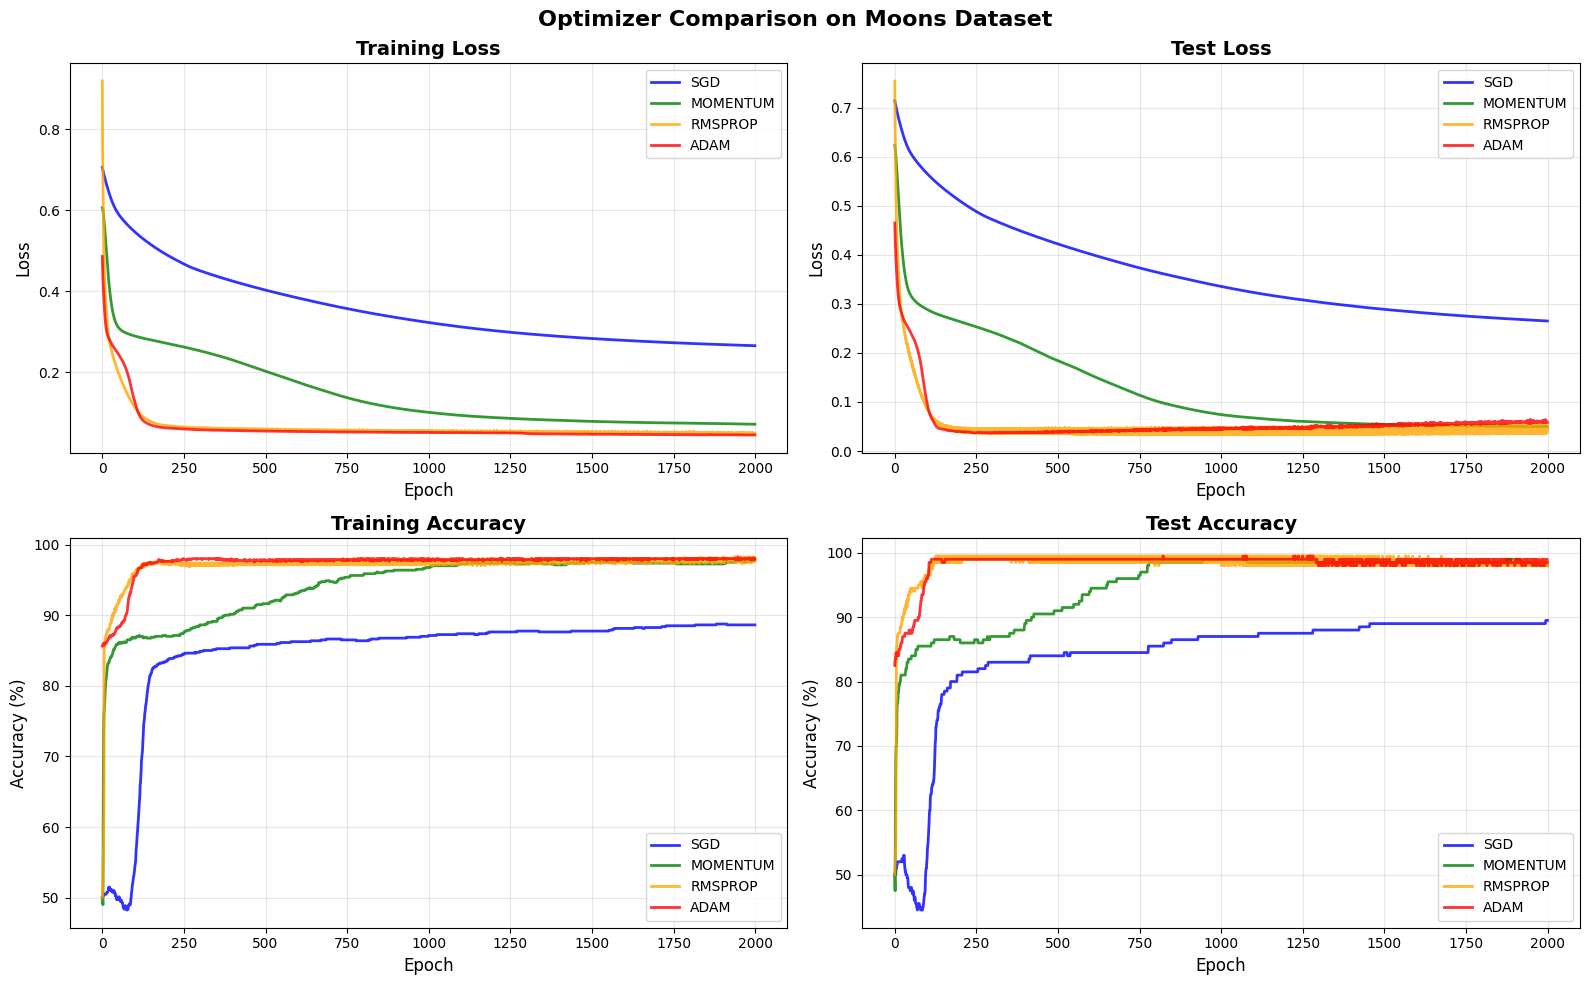

In [ ]:
# ============================================
# PLOT TRAINING CURVES
# ============================================

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Optimizer Comparison on Moons Dataset', fontsize=16, fontweight='bold')

# Colors for each optimizer
colors = {'sgd': 'blue', 'momentum': 'green', 'rmsprop': 'orange', 'adam': 'red'}

# Plot 1: Training Loss
ax = axes[0, 0]
for opt in optimizers:
    ax.plot(results[opt]['history']['train_loss'],
            label=opt.upper(), color=colors[opt], linewidth=2, alpha=0.8)
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Loss', fontsize=12)
ax.set_title('Training Loss', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# Plot 2: Test Loss
ax = axes[0, 1]
for opt in optimizers:
    ax.plot(results[opt]['history']['test_loss'],
            label=opt.upper(), color=colors[opt], linewidth=2, alpha=0.8)
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Loss', fontsize=12)
ax.set_title('Test Loss', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# Plot 3: Training Accuracy
ax = axes[1, 0]
for opt in optimizers:
    ax.plot(results[opt]['history']['train_acc'],
            label=opt.upper(), color=colors[opt], linewidth=2, alpha=0.8)
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_title('Training Accuracy', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# Plot 4: Test Accuracy
ax = axes[1, 1]
for opt in optimizers:
    ax.plot(results[opt]['history']['test_acc'],
            label=opt.upper(), color=colors[opt], linewidth=2, alpha=0.8)
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_title('Test Accuracy', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Step 13: Visualize Decision Boundaries

Let's see how each optimizer's trained network separates the two classes.

## Decision Boundary:
- Shows regions where network predicts each class
- Color intensity indicates confidence
- Helps visualize if network learned the pattern correctly

This visualization will show if different optimizers found similar or different solutions.

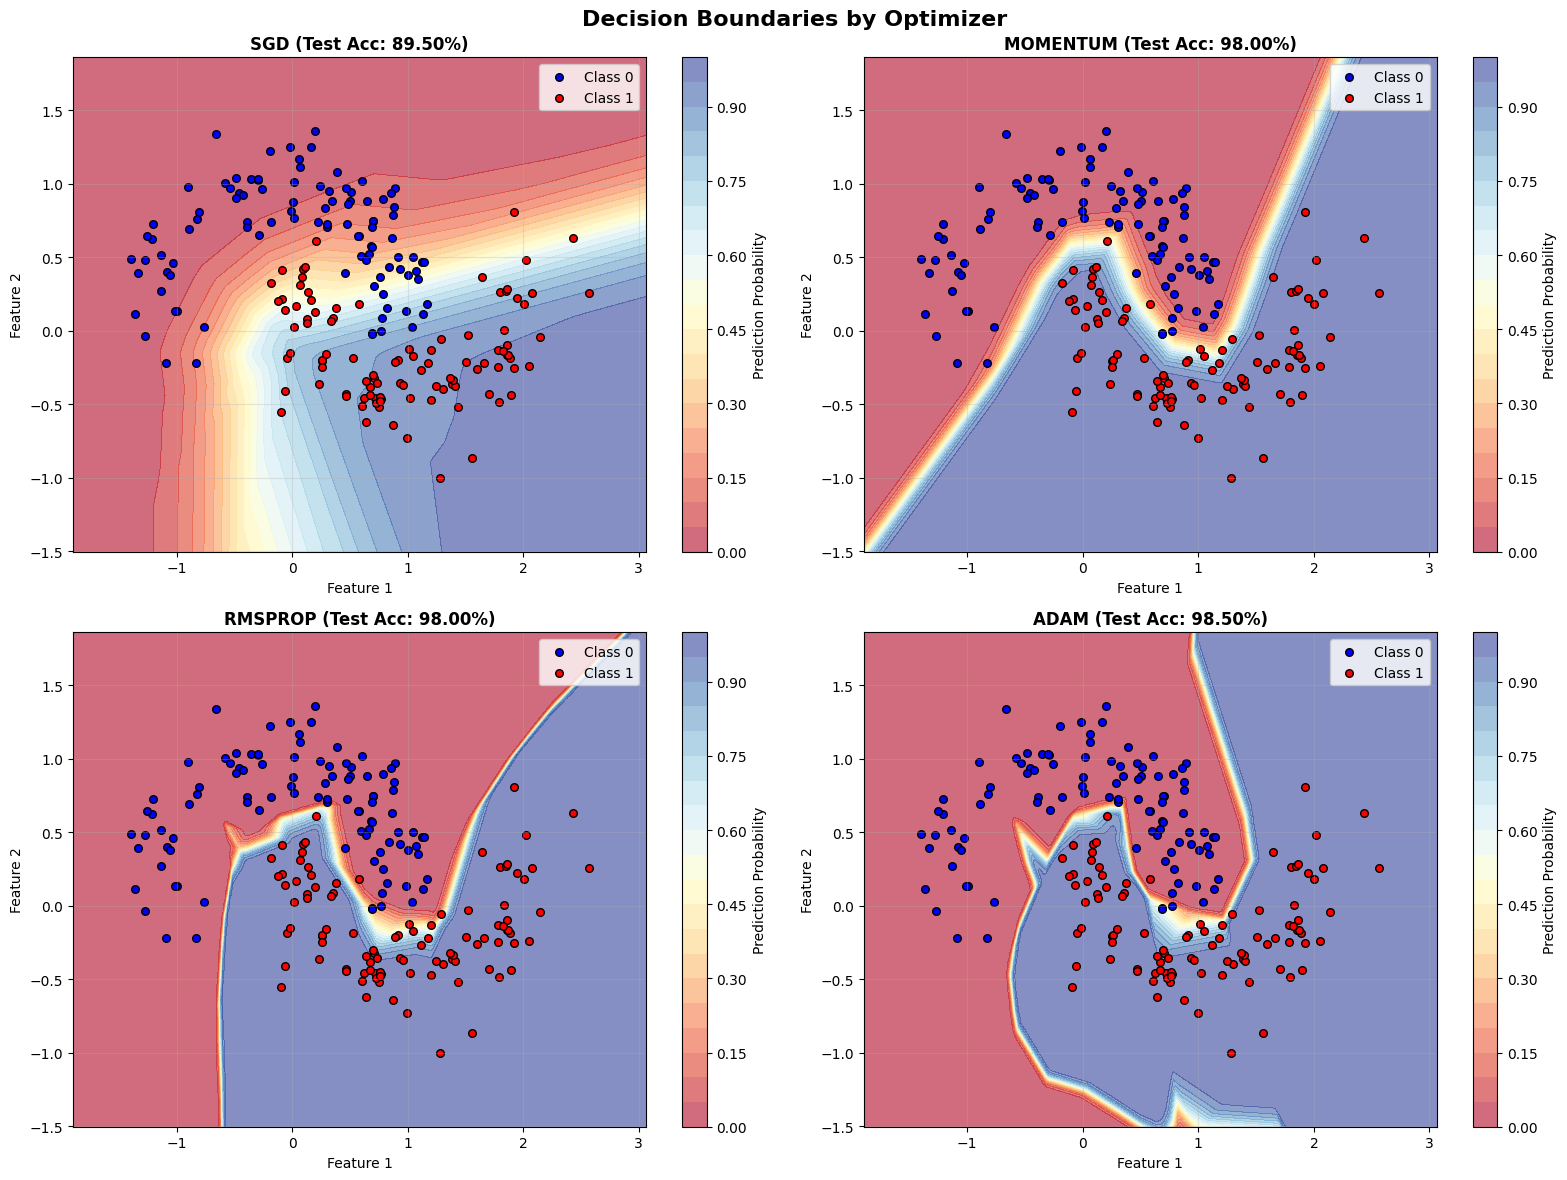

In [ ]:
# ============================================
# PLOT DECISION BOUNDARIES
# ============================================

def plot_decision_boundary(X, y, weights, biases, activation, title):
    """Plot decision boundary for binary classification"""
    # Create mesh
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    h = 0.02
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))

    # Predict on mesh
    mesh_input = np.c_[xx.ravel(), yy.ravel()]
    Z, _ = forward_propagation(mesh_input, weights, biases, activation)
    Z = Z.reshape(xx.shape)

    # Plot
    plt.contourf(xx, yy, Z, levels=20, cmap='RdYlBu', alpha=0.6)
    plt.colorbar(label='Prediction Probability')
    plt.scatter(X[y.flatten()==0, 0], X[y.flatten()==0, 1],
                c='blue', label='Class 0', edgecolors='k', s=30)
    plt.scatter(X[y.flatten()==1, 0], X[y.flatten()==1, 1],
                c='red', label='Class 1', edgecolors='k', s=30)
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.title(title, fontweight='bold')
    plt.legend()
    plt.grid(True, alpha=0.3)

# Plot decision boundaries for all optimizers
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Decision Boundaries by Optimizer', fontsize=16, fontweight='bold')

for idx, opt in enumerate(optimizers):
    plt.subplot(2, 2, idx + 1)
    acc = results[opt]['final_test_acc']
    plot_decision_boundary(
        X_test, y_test,
        results[opt]['weights'],
        results[opt]['biases'],
        activation,
        f'{opt.upper()} (Test Acc: {acc:.2f}%)'
    )

plt.tight_layout()
plt.show()

# Summary: Optimizer Comparison

## Expected Results:

### 1. **SGD (Stochastic Gradient Descent)**
- **Pros**: Simple, predictable
- **Cons**: Slowest convergence, can oscillate
- **Use when**: Small problems, when you understand the problem well

### 2. **SGD with Momentum**
- **Pros**: Faster than SGD, smoother updates
- **Cons**: One more hyperparameter (beta)
- **Use when**: You want faster convergence than SGD without much complexity

### 3. **RMSprop**
- **Pros**: Adapts learning rate, good for non-stationary problems
- **Cons**: Can be sensitive to learning rate
- **Use when**: Dealing with sparse gradients or recurrent networks

### 4. **Adam**
- **Pros**: Fast convergence, works well out-of-the-box, adapts to problem
- **Cons**: More complex, uses more memory
- **Use when**: Default choice for most deep learning problems

---

## Key Results:

1. **Adam typically performs best** for most problems with default settings
2. **Momentum helps** by accelerating convergence and reducing oscillations
3. **Adaptive methods** (RMSprop, Adam) automatically adjust learning rates
4. **Trade-offs exist**: Simplicity vs. performance vs. memory

---

## Practical Tips:

 - **Start with Adam** - it's the most reliable default choice
 - **Tune learning rate first** - biggest impact on performance
 - **Use momentum** if you want balance between simplicity and performance
 - **Monitor training curves** - they tell you if something is wrong

---

## Lab Exercises for Students:

1. **Change learning rates** (0.001, 0.01, 0.1) - observe effects
2. **Add more hidden layers** - does best optimizer change?
3. **Try different activation functions** (sigmoid, tanh)
4. **Modify momentum beta** - how does it affect convergence?
5. **Implement learning rate decay** - combine with SGD
6. **Try on XOR problem** - simpler dataset to debug
7. **Add regularization** (L2) - prevent overfitting

---

In [ ]:

# FINAL PERFORMANCE SUMMARY


print("\n" + "="*80)
print("FINAL SUMMARY")
print("="*80)

# Calculate convergence speed (epochs to reach 90% of final accuracy)
print("\nConvergence Speed (epochs to reach 90% of final accuracy):")
print("-"*80)
for opt in optimizers:
    final_acc = results[opt]['final_test_acc']
    target = 0.9 * final_acc
    history = results[opt]['history']['test_acc']
    epochs_to_target = next((i for i, acc in enumerate(history) if acc >= target), len(history))
    print(f"{opt.upper():<15} {epochs_to_target:>5} epochs")

# Calculate training stability (variance of loss in last 20% of training)
print("\nTraining Stability (lower is better - std of loss in last 20% of training):")
print("-"*80)
for opt in optimizers:
    last_20_percent = int(0.8 * len(results[opt]['history']['train_loss']))
    recent_loss = results[opt]['history']['train_loss'][last_20_percent:]
    stability = np.std(recent_loss)
    print(f"{opt.upper():<15} {stability:>8.6f}")

print("\n" + "="*80)
print("Recommendation: Use Adam for most problems")
print("="*80)


FINAL SUMMARY

Convergence Speed (epochs to reach 90% of final accuracy):
--------------------------------------------------------------------------------
SGD               191 epochs
MOMENTUM          397 epochs
RMSPROP            17 epochs
ADAM               59 epochs

Training Stability (lower is better - std of loss in last 20% of training):
--------------------------------------------------------------------------------
SGD             0.003782
MOMENTUM        0.001376
RMSPROP         0.001323
ADAM            0.000423

Recommendation: Use Adam for most problems


## Lab Tasks:

1. **Change learning rates** (0.001, 0.01, 0.1) - observe effects
2. **Add more hidden layers** - does best optimizer change?
3. **Try different activation functions** (sigmoid, tanh)
4. **Modify momentum beta** - how does it affect convergence?
5. **Implement learning rate decay** - combine with SGD
6. **Try on XOR problem** - simpler dataset to debug
7. **Add regularization** (L2) - prevent overfitting